# BrainBoard — Ensemble Classifier for EEG Motor Imagery

**Cel:** porównanie pojedynczych klasyfikatorów i zbudowanie ensemble (voting + stacking), który łączy ich predykcje, by zmaksymalizować accuracy.

| Etap | Zawartość |
|------|-----------|
| 1 | Ładowanie danych (10–15 subjectów, pasmo 8–30 Hz) |
| 2 | Ekstrakcja cech: CSP, Band Power, Combined |
| 3 | Baseline — 8 pojedynczych modeli × 3 zestawy cech |
| 4 | **Voting Ensemble** — soft (ważone prob.) + hard (majority vote) |
| 5 | **Stacking Ensemble** — meta-learner (Logistic Regression) |
| 6 | Finalne porównanie + macierze pomyłek |

> Dane: PhysioNet EEG Motor Movement/Imagery Dataset (Schalk et al., 2004)  
> Framework: `scikit-learn` + `mne`

## Krok 1 — Instalacja zależności

Instaluje biblioteki potrzebne do analizy EEG i trenowania modeli: `mne` do przetwarzania sygnałów, `scikit-learn` do klasyfikacji i budowy ensemble, `kagglehub` do pobrania datasetu. Wystarczy uruchomić raz na początku sesji w Colab.

In [1]:
!pip install mne scikit-learn kagglehub seaborn scipy --quiet

## Krok 2 — Import bibliotek

Importuje wszystkie potrzebne moduły: biblioteki numeryczne (`numpy`, `scipy`), wizualizację (`matplotlib`, `seaborn`), przetwarzanie EEG (`mne`) oraz cały stos klasyfikatorów i narzędzi z `scikit-learn`. Ustawia też globalne wyciszenie ostrzeżeń i styl wykresów.

In [2]:
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import re
import warnings
import pandas as pd
from pathlib import Path
from collections import defaultdict

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, VotingClassifier, StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict,
)
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from mne.decoding import CSP
from scipy.signal import welch

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')
sns.set_theme(style='whitegrid')
print("Imports OK ✓")

Imports OK ✓


## Krok 3 — Pobranie datasetu z Kaggle

Pobiera PhysioNet EEG Motor Movement/Imagery Dataset przez `kagglehub` i zapisuje go lokalnie. Następnie rekurencyjnie wyszukuje wszystkie pliki `.edf` w pobranym katalogu — powinno ich być ok. 1526.

In [3]:
path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")
dataset_path = Path(path)
edf_files = list(dataset_path.rglob("*.edf"))
print(f"Znaleziono {len(edf_files)} plików EDF")

Znaleziono 1526 plików EDF


## Krok 4 — Ładowanie danych z wielu subjectów

Definiuje funkcje pomocnicze do parsowania nazw plików, mapowania numerów runów na klasy eventów (Left Fist, Right Fist, Both Fists, Both Feet) oraz czyszczenia nazw kanałów pod montaż `standard_1005`. Następnie w pętli wczytuje pliki EDF dla `N_SUBJECTS` subjectów, stosuje filtr pasmowy 8–30 Hz, tnie sygnał na epoki w oknie -0.5 s do +4 s i składa wszystko w tensor `X_raw` (epoki × kanały × czas) oraz wektor etykiet `y`.

In [4]:
MOTOR_EXEC_LR = [3, 7, 11]
MOTOR_EXEC_FF = [4, 8, 12]
IMAGERY_LR    = [5, 9, 13]
IMAGERY_FF    = [6, 10, 14]
ALL_TASK_RUNS = IMAGERY_LR  # tylko imagery Left vs Right (binary)

def parse_filename(filepath):
    m = re.match(r'S(\d+)R(\d+)', filepath.stem)
    return (int(m.group(1)), int(m.group(2))) if m else (None, None)

def get_run_event_mapping(run_num):
    if run_num in MOTOR_EXEC_LR + IMAGERY_LR:
        return {'T1': 'Left Fist', 'T2': 'Right Fist'}
    if run_num in MOTOR_EXEC_FF + IMAGERY_FF:
        return {'T1': 'Both Fists', 'T2': 'Both Feet'}
    return {}

def clean_channel_names(raw):
    mapping = {ch: ch.rstrip('.') for ch in raw.ch_names if ch.endswith('.')}
    if mapping:
        raw.rename_channels(mapping)
    montage = mne.channels.make_standard_montage('standard_1005')
    lower   = {ch.lower(): ch for ch in montage.ch_names}
    case_map = {ch: lower[ch.lower()] for ch in raw.ch_names
                if ch.lower() in lower and lower[ch.lower()] != ch}
    if case_map:
        raw.rename_channels(case_map)
    try:
        raw.set_montage(montage, on_missing='ignore')
    except Exception:
        pass
    return raw

N_SUBJECTS = 15     # ← zwiększ dla lepszych wyników (kosztem czasu)
TMIN, TMAX = -0.5, 4.0
L_FREQ, H_FREQ = 8.0, 30.0

subjects_files = defaultdict(list)
for f in edf_files:
    subj, run = parse_filename(f)
    if subj is not None and run in ALL_TASK_RUNS:
        subjects_files[subj].append((run, f))

subject_ids = sorted(subjects_files.keys())[:N_SUBJECTS]
epoch_list, label_list, sfreq_ref = [], [], None

print(f"Ładowanie {N_SUBJECTS} subjectów (filtr {L_FREQ}–{H_FREQ} Hz)...")

for subj_id in subject_ids:
    for run_num, filepath in subjects_files[subj_id]:
        ev_map = get_run_event_mapping(run_num)
        if not ev_map:
            continue
        try:
            raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
            raw = clean_channel_names(raw)
            raw.filter(L_FREQ, H_FREQ, method='iir', verbose=False)
            if sfreq_ref is None:
                sfreq_ref = raw.info['sfreq']

            events, event_dict = mne.events_from_annotations(raw, verbose=False)
            mapped = {name: event_dict[ann]
                      for ann, name in ev_map.items() if ann in event_dict}
            if not mapped:
                continue

            epochs = mne.Epochs(raw, events, event_id=mapped,
                                tmin=TMIN, tmax=TMAX,
                                baseline=None, preload=True, verbose=False)
            epochs.drop_bad(verbose=False)

            for cls_name in mapped:
                eps = epochs[cls_name]
                if len(eps) > 0:
                    epoch_list.append(eps.get_data())
                    label_list.extend([cls_name] * len(eps))
        except Exception:
            continue

X_raw = np.concatenate(epoch_list, axis=0)   # (n_epochs, n_ch, n_times)
y_str = np.array(label_list)

le = LabelEncoder()
y  = le.fit_transform(y_str)
n_classes = len(le.classes_)

print(f"\n✓ Dataset: {X_raw.shape[0]} epok, "
      f"{X_raw.shape[1]} kanałów, {X_raw.shape[2]} próbek/epokę")
print(f"  Sfreq: {sfreq_ref} Hz  |  Klasy ({n_classes}): {list(le.classes_)}")
for i, cls in enumerate(le.classes_):
    print(f"    [{i}] {cls}: {(y == i).sum()} epok")

Ładowanie 15 subjectów (filtr 8.0–30.0 Hz)...

✓ Dataset: 675 epok, 64 kanałów, 721 próbek/epokę
  Sfreq: 160.0 Hz  |  Klasy (2): [np.str_('Left Fist'), np.str_('Right Fist')]
    [0] Left Fist: 334 epok
    [1] Right Fist: 341 epok


## Krok 5 — Ekstrakcja cech

Definiuje transformery kompatybilne z sklearn:
- `CSPTransformer` — wrapper na `mne.decoding.CSP` działający wewnątrz `Pipeline`, fitowany **wyłącznie na danych treningowych** (brak data leakage)
- `BandPower` — log-moc w pasmach Mu i Beta per kanał (Welch), nie wymaga fitowania na etykietach

Trzy zestawy cech: CSP, Band Power, Combined — ale CSP jest teraz wyciągane wewnątrz CV, nie na pełnym zbiorze.


In [5]:
class CSPTransformer(BaseEstimator, TransformerMixin):
    """Wrapper on mne CSP that works inside sklearn Pipeline.
    CSP is fitted only on training data — no leakage."""
    def __init__(self, n_components=8, log=True, norm_trace=False):
        self.n_components = n_components
        self.log = log
        self.norm_trace = norm_trace

    def fit(self, X, y=None):
        self.csp_ = CSP(n_components=self.n_components,
                        log=self.log, norm_trace=self.norm_trace)
        self.csp_.fit(X, y)
        return self

    def transform(self, X):
        return self.csp_.transform(X)


class BandPower(BaseEstimator, TransformerMixin):
    """Log-band-power per channel.
    Input:  (n_epochs, n_channels, n_times)
    Output: (n_epochs, n_channels * n_bands)
    """
    def __init__(self, sfreq=160, bands=None):
        self.sfreq = sfreq
        self.bands = bands or {'mu': (8, 13), 'beta': (13, 30)}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for fmin, fmax in self.bands.values():
            freqs, psd = welch(X, self.sfreq,
                               nperseg=min(X.shape[-1], 256), axis=-1)
            mask = (freqs >= fmin) & (freqs <= fmax)
            bp = np.log(np.mean(psd[..., mask], axis=-1) + 1e-10)
            features.append(bp)
        return np.hstack(features)


class CombinedFeatures(BaseEstimator, TransformerMixin):
    """Concatenates CSP + BandPower features. Both fitted inside CV."""
    def __init__(self, n_csp=8, sfreq=160):
        self.n_csp = n_csp
        self.sfreq = sfreq

    def fit(self, X, y=None):
        self.csp_ = CSPTransformer(n_components=self.n_csp)
        self.bp_  = BandPower(sfreq=self.sfreq)
        self.csp_.fit(X, y)
        self.bp_.fit(X, y)
        return self

    def transform(self, X):
        return np.hstack([self.csp_.transform(X), self.bp_.transform(X)])


N_CSP = 8

# Pre-extract BandPower (no leakage — unsupervised)
bp_extractor = BandPower(sfreq=sfreq_ref)
X_bp = bp_extractor.transform(X_raw)

print(f"BandPower features: {X_bp.shape}")
print(f"CSP i Combined będą wyciągane wewnątrz CV (brak leakage).")
print(f"X_raw shape (input do pipeline): {X_raw.shape}")


BandPower features: (675, 128)
CSP i Combined będą wyciągane wewnątrz CV (brak leakage).
X_raw shape (input do pipeline): (675, 64, 721)


## Krok 6 — Baseline: 8 pojedynczych klasyfikatorów

Dla cech **Band Power** (unsupervised) używamy standardowego `Pipeline(Scaler → Clf)`.
Dla cech **CSP** i **Combined** transformery są wewnątrz pipeline — CSP fituje się **tylko na train fold**, co eliminuje data leakage.


In [6]:
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'balanced_accuracy'

def make_pipe(clf):
    """Pipeline for pre-extracted features (BandPower)."""
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

def make_csp_pipe(clf):
    """Pipeline with CSP inside — no leakage."""
    return Pipeline([
        ('csp',    CSPTransformer(n_components=N_CSP)),
        ('scaler', StandardScaler()),
        ('clf',    clf),
    ])

def make_combined_pipe(clf):
    """Pipeline with Combined (CSP+BP) inside — no leakage."""
    return Pipeline([
        ('features', CombinedFeatures(n_csp=N_CSP, sfreq=sfreq_ref)),
        ('scaler',   StandardScaler()),
        ('clf',      clf),
    ])

# Base classifiers (raw instances, will be wrapped in pipelines)
BASE_CLFS = {
    'LDA':               LinearDiscriminantAnalysis(),
    'SVM-RBF':           SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'SVM-Linear':        SVC(kernel='linear', C=0.1, probability=True, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'Extra Trees':       ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'MLP':               MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
    'kNN':               KNeighborsClassifier(n_neighbors=7),
}

# Build pipelines per feature set
# CSP/Combined: transformer inside pipeline (leakage-free)
# BandPower: pre-extracted (unsupervised, no leakage)
FEAT_CONFIGS = {
    'CSP':        {'X': X_raw, 'pipe_fn': make_csp_pipe},
    'Band Power': {'X': X_bp,  'pipe_fn': make_pipe},
    'Combined':   {'X': X_raw, 'pipe_fn': make_combined_pipe},
}

# Store full pipeline objects for later reuse (ensemble, confusion matrices)
BASE_MODELS = {}  # key: model_name, value: combined pipeline

baseline_results = {}
print(f"Ewaluacja {len(BASE_CLFS)} modeli × {len(FEAT_CONFIGS)} zestawów cech "
      f"({CV.n_splits}-fold CV)...\n")

for feat_name, cfg in FEAT_CONFIGS.items():
    print(f"── {feat_name} ──────────────────────────────────────────")
    for model_name, clf in BASE_CLFS.items():
        pipe = cfg['pipe_fn'](clone(clf))
        scores = cross_val_score(pipe, cfg['X'], y, cv=CV,
                                 scoring=SCORING, n_jobs=-1)
        key = f'{model_name} | {feat_name}'
        baseline_results[key] = scores
        # Store Combined pipeline for ensemble building
        if feat_name == 'Combined':
            BASE_MODELS[model_name] = pipe
        print(f"  {model_name:<22s}  {scores.mean():.3f} ± {scores.std():.3f}")
    print()

print("✓ Baseline gotowy (CSP fitowany wewnątrz CV — brak leakage)")


Ewaluacja 8 modeli × 3 zestawów cech (5-fold CV)...

── CSP ──────────────────────────────────────────
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00085 (2.2e-16 eps * 64 dim * 6e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00084 (2.2e-16 eps * 64 dim * 5.9e+10  max singular value)
   

/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptro

  MLP                     0.741 ± 0.041
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00085 (2.2e-16 eps * 64 dim * 6e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00084 (2.2e-16 eps * 64 dim * 5.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 d

## Krok 7 — Wizualizacja wyników baseline

Rysuje trzy poziome wykresy słupkowe (jeden per zestaw cech) z wynikami wszystkich modeli posortowanymi od najsłabszego do najsilniejszego. Kolory słupków skalują się od czerwonego (wynik bliski losowemu) do zielonego (dobry wynik), a czerwona linia przerywana zaznacza poziom losowy `1 / n_classes`.

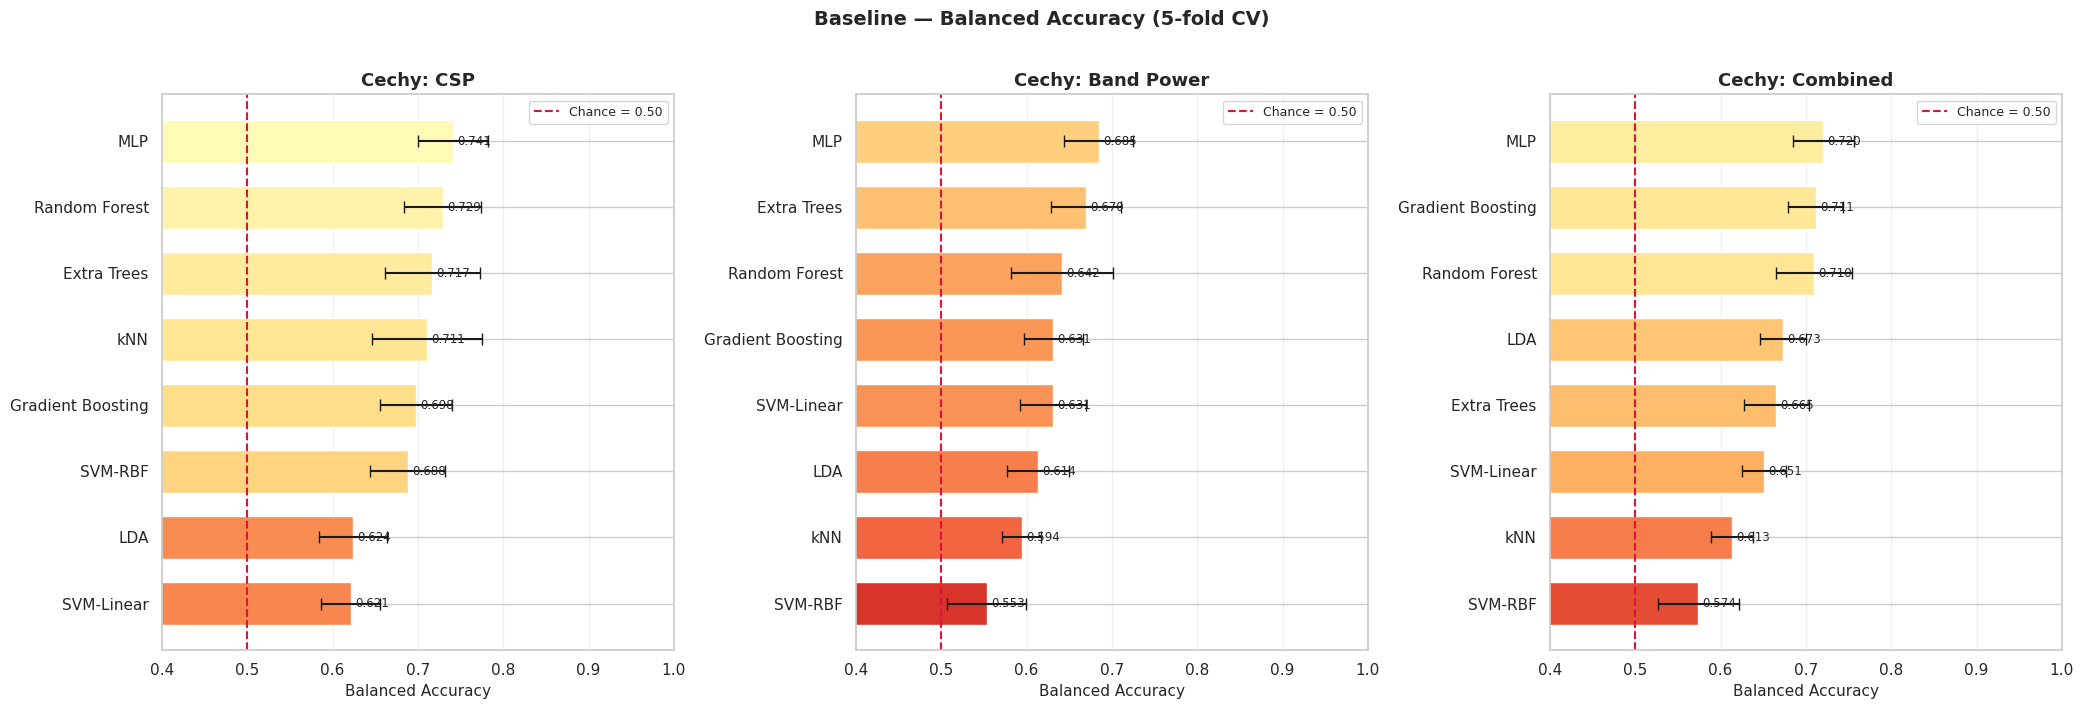


🏆 Top-5 pojedynczych modeli:
            model features     mean      std
              MLP      CSP 0.740893 0.040732
    Random Forest      CSP 0.728904 0.045529
              MLP Combined 0.720342 0.035756
      Extra Trees      CSP 0.717050 0.055198
Gradient Boosting Combined 0.711407 0.032462


In [7]:
df_base = pd.DataFrame([
    {'model':    k.split(' | ')[0],
     'features': k.split(' | ')[1],
     'mean':     v.mean(),
     'std':      v.std()}
    for k, v in baseline_results.items()
])

chance = 1.0 / n_classes
fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=False)

for ax, feat_name in zip(axes, ['CSP', 'Band Power', 'Combined']):
    sub = df_base[df_base['features'] == feat_name].sort_values('mean')
    norm = (sub['mean'] - chance) / (1 - chance)  # normalize to [0,1] above chance
    colors = plt.cm.RdYlGn(norm.clip(0, 1).values)

    bars = ax.barh(sub['model'], sub['mean'], xerr=sub['std'],
                   color=colors, edgecolor='white', height=0.65, capsize=4)
    ax.axvline(chance, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Chance = {chance:.2f}')
    ax.set_xlim(max(0, chance - 0.1), 1.0)
    ax.set_title(f'Cechy: {feat_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Balanced Accuracy', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{row["mean"]:.3f}', va='center', fontsize=8.5)

plt.suptitle('Baseline — Balanced Accuracy (5-fold CV)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

top5 = df_base.nlargest(5, 'mean')[['model', 'features', 'mean', 'std']]
print("\n🏆 Top-5 pojedynczych modeli:")
print(top5.to_string(index=False))

## Krok 8 — Voting Ensemble

Automatycznie wybiera top-5 modeli z wyników baseline na cechach Combined i klonuje świeże instancje do ensemble. Buduje dwa warianty: `voting_soft` sumuje prawdopodobieństwa klas ważone accuracy z baseline, `voting_hard` stosuje zwykłe głosowanie większościowe — oba są oceniane tym samym 5-fold CV.

In [8]:
N_TOP = 5
top_rows = (df_base[df_base['features'] == 'Combined']
            .nlargest(N_TOP, 'mean'))
top_names   = top_rows['model'].tolist()
top_weights = top_rows['mean'].tolist()

print(f"Top-{N_TOP} modele wybrane do ensemble:")
for n, w in zip(top_names, top_weights):
    print(f"  {n:<22s}  acc={w:.3f}")

# Clone fresh Combined pipelines (CSP inside!)
top_estimators = [
    (name.replace(' ', '_').replace('-', '_'), clone(BASE_MODELS[name]))
    for name in top_names
]

voting_soft = VotingClassifier(
    estimators=top_estimators,
    voting='soft',
    weights=top_weights,
    n_jobs=-1,
)

voting_hard = VotingClassifier(
    estimators=top_estimators,
    voting='hard',
    n_jobs=-1,
)

ensemble_results = {}
print("\nEwaluacja Voting Ensemble (na X_raw — CSP wewnątrz pipeline)...")
for name, clf in [('Voting Soft (weighted)', voting_soft),
                  ('Voting Hard',            voting_hard)]:
    scores = cross_val_score(clf, X_raw, y, cv=CV, scoring=SCORING)
    ensemble_results[name] = scores
    print(f"  {name:<28s}  {scores.mean():.3f} ± {scores.std():.3f}")


Top-5 modele wybrane do ensemble:
  MLP                     acc=0.720
  Gradient Boosting       acc=0.711
  Random Forest           acc=0.710
  LDA                     acc=0.673
  Extra Trees             acc=0.665

Ewaluacja Voting Ensemble (na X_raw — CSP wewnątrz pipeline)...
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank 

## Krok 9 — Stacking Ensemble

Buduje `StackingClassifier` na tych samych top-5 modelach co voting: każdy base learner generuje out-of-fold predykcje prawdopodobieństw za pomocą wbudowanego 5-fold CV, a Logistic Regression jako meta-learner uczy się optymalnych wag dla każdego modelu na podstawie tych predykcji. Wynik oceniany jest zewnętrznym 5-fold CV.

In [9]:
stacking = StackingClassifier(
    estimators=top_estimators,
    final_estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('meta',   LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ]),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

print("Ewaluacja Stacking Ensemble (na X_raw — CSP wewnątrz pipeline)...")
scores = cross_val_score(stacking, X_raw, y, cv=CV, scoring=SCORING)
ensemble_results['Stacking (LR meta)'] = scores
print(f"  Stacking (LR meta):          {scores.mean():.3f} ± {scores.std():.3f}")


Ewaluacja Stacking Ensemble (na X_raw — CSP wewnątrz pipeline)...
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data

## Krok 10 — Finalne porównanie: baseline vs ensemble

Zbiera wyniki wszystkich baseline'ów (tylko na cechach Combined, żeby porównanie było uczciwe) i obu metod ensemble w jeden DataFrame, a następnie rysuje wspólny wykres słupkowy z kolorami niebieski/czerwony dla baseline/ensemble. Na końcu drukuje nazwę i wynik najlepszego modelu spośród wszystkich.

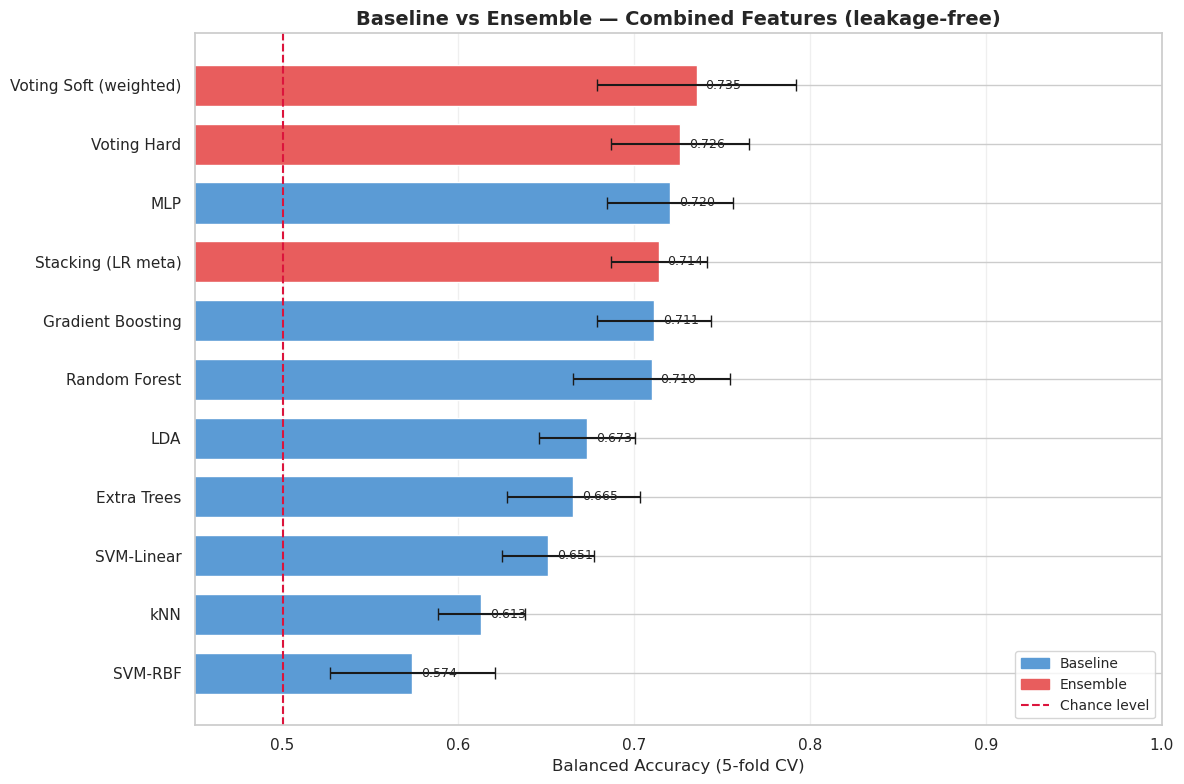


🥇 Najlepszy model: Voting Soft (weighted)  →  0.735 balanced accuracy


In [10]:
all_results = {}

# Baseline: tylko Combined (fair comparison z ensemble)
for k, v in baseline_results.items():
    if k.endswith('| Combined'):
        all_results[k.replace(' | Combined', '')] = v

# Ensemble
all_results.update(ensemble_results)

df_all = pd.DataFrame([
    {'name': k, 'mean': v.mean(), 'std': v.std(),
     'type': 'Ensemble' if k.startswith(('Voting', 'Stacking')) else 'Baseline'}
    for k, v in all_results.items()
]).sort_values('mean', ascending=True)

palette = {'Baseline': '#5B9BD5', 'Ensemble': '#E85D5D'}
colors  = df_all['type'].map(palette).values

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_all['name'], df_all['mean'], xerr=df_all['std'],
               color=colors, edgecolor='white', height=0.7, capsize=4)

ax.axvline(chance, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Poziom losowy ({chance:.2f})')
ax.set_xlim(max(0, chance - 0.05), 1.0)
ax.set_xlabel('Balanced Accuracy (5-fold CV)', fontsize=12)
ax.set_title('Baseline vs Ensemble — Combined Features (leakage-free)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in palette.items()]
legend_handles.append(plt.Line2D([0], [0], color='crimson',
                                 linestyle='--', label='Chance level'))
ax.legend(handles=legend_handles, fontsize=10, loc='lower right')

for bar, (_, row) in zip(bars, df_all.iterrows()):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{row["mean"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

best_name = df_all.loc[df_all['mean'].idxmax(), 'name']
best_acc  = df_all['mean'].max()
print(f"\n🥇 Najlepszy model: {best_name}  →  {best_acc:.3f} balanced accuracy")


## Krok 11 — Macierze pomyłek

Automatycznie wyłania najlepszy baseline i najlepszy ensemble z poprzedniego kroku, a następnie generuje dla każdego z nich predykcje out-of-fold przez `cross_val_predict` (bez ryzyka przeuczenia). Rysuje dwie macierze pomyłek obok siebie i drukuje pełny classification report dla najlepszego ensemble.

Best baseline:  MLP
Best ensemble:  Voting Soft (weighted)
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 

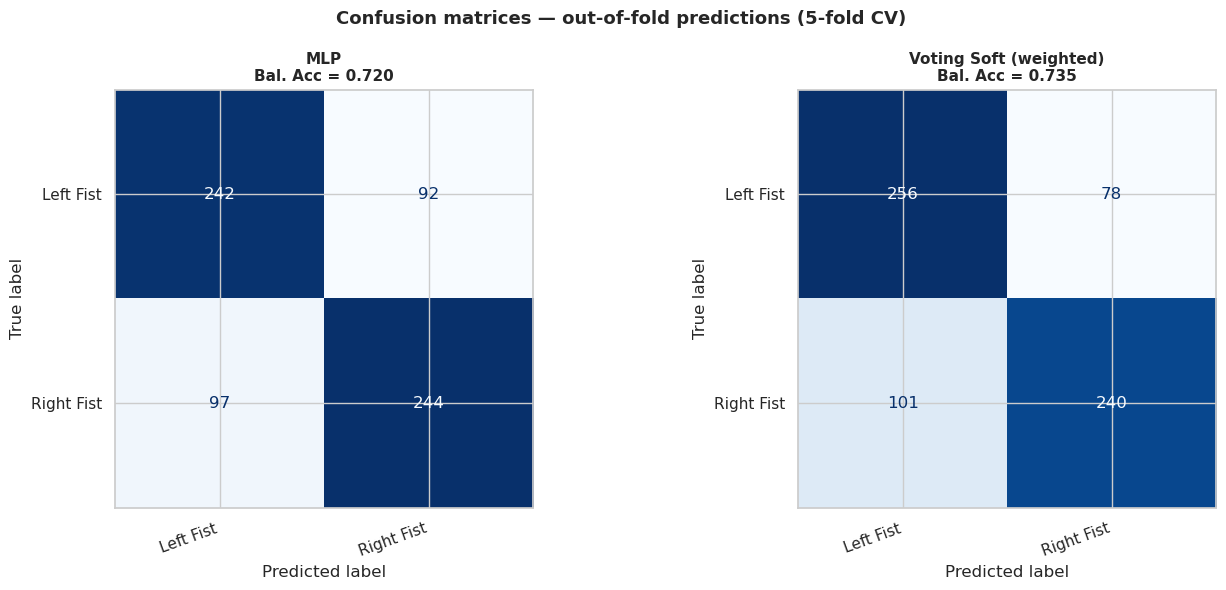


Classification Report: Voting Soft (weighted)
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Using tolerance 0.00083 (2.2e-16 eps * 64 dim * 5.8e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Reducing data rank from 64 -> 64
Estimating class=0 covariance using EMPIRICAL
Done.
Done.
Estimating class=1 covariance using EMPIRICAL
Estimating class=1 covariance using EMPIRICAL
Done.
Done.
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.00083 (2.2e-16 eps * 

In [11]:
# Best baseline on Combined features
best_baseline_name = (df_all[df_all['type'] == 'Baseline']
                      .sort_values('mean', ascending=False)
                      ['name'].iloc[0])

# Best ensemble
best_ensemble_name = (df_all[df_all['type'] == 'Ensemble']
                      .sort_values('mean', ascending=False)
                      ['name'].iloc[0])

print(f"Best baseline:  {best_baseline_name}")
print(f"Best ensemble:  {best_ensemble_name}")

model_lookup = {
    name: clone(BASE_MODELS[name])
    for name in BASE_MODELS
}
model_lookup['Voting Soft (weighted)'] = clone(voting_soft)
model_lookup['Voting Hard']            = clone(voting_hard)
model_lookup['Stacking (LR meta)']     = clone(stacking)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name in zip(axes, [best_baseline_name, best_ensemble_name]):
    clf    = model_lookup[name]
    y_pred = cross_val_predict(clf, X_raw, y, cv=CV)  # X_raw — CSP inside pipeline
    acc    = balanced_accuracy_score(y, y_pred)
    cm     = confusion_matrix(y, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nBal. Acc = {acc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Confusion matrices — out-of-fold predictions (5-fold CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClassification Report: {best_ensemble_name}")
clf    = model_lookup[best_ensemble_name]
y_pred = cross_val_predict(clf, X_raw, y, cv=CV)
print(classification_report(y, y_pred, target_names=le.classes_))


## Krok 12 (Bonus) — Ważność cech w najlepszym modelu drzewiastym

Jeśli Random Forest lub Extra Trees znalazł się wśród wyników, trenuje go na pełnym zbiorze `X_combined` i odczytuje `feature_importances_` z wytrenowanego drzewa. Rysuje słupkowy wykres top-20 najważniejszych cech z rozróżnieniem kolorystycznym między komponentami CSP (czerwony) a kanałami Band Power (niebieski).

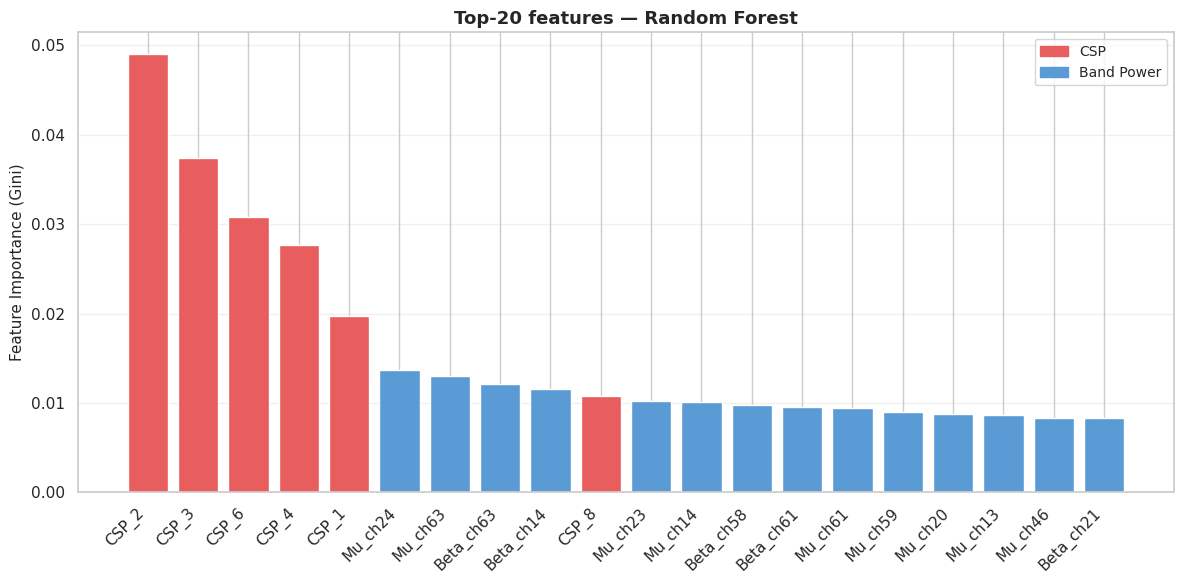

In [12]:
tree_candidate = next(
    (n for n in df_all.sort_values('mean', ascending=False)['name']
     if n in ('Random Forest', 'Extra Trees')),
    None,
)

if tree_candidate is None:
    print("No tree-based model in results — skip this cell.")
else:
    tree_clf = clone(BASE_MODELS[tree_candidate])
    tree_clf.fit(X_raw, y)  # full fit for feature importance (not for eval!)
    
    # Get importances from the classifier step
    importances = tree_clf.named_steps['clf'].feature_importances_
    
    # Feature names: CSP components + BandPower channels
    csp_feat_names = [f'CSP_{i+1}' for i in range(N_CSP)]
    bp_feat_names  = (
        [f'Mu_ch{i+1}'   for i in range(X_raw.shape[1])] +
        [f'Beta_ch{i+1}' for i in range(X_raw.shape[1])]
    )
    feat_names = csp_feat_names + bp_feat_names
    
    # Safety check: match feature count
    if len(importances) != len(feat_names):
        print(f"Warning: {len(importances)} importances vs {len(feat_names)} names")
        feat_names = [f'feat_{i}' for i in range(len(importances))]

    top_n = min(20, len(importances))
    idx   = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(12, 6))
    colors_feat = ['#E85D5D' if 'CSP' in feat_names[i] else '#5B9BD5' for i in idx]
    ax.bar(range(top_n), importances[idx], color=colors_feat, edgecolor='white')
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([feat_names[i] for i in idx], rotation=45, ha='right')
    ax.set_ylabel('Feature Importance (Gini)', fontsize=11)
    ax.set_title(f'Top-{top_n} features — {tree_candidate}',
                 fontsize=13, fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#E85D5D', label='CSP'),
                       Patch(color='#5B9BD5', label='Band Power')],
              fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
